In [7]:
import pandas as pd
import os

# Set file paths (adjust if needed)
file_paths = {
    "Potato": "Potato Agmarknet_Price_Report.xls",
    "Tomato": "Tomato Agmarknet_Price_Report.xls",
    "Brinjal": "Brinjal Agmarknet_Price_Report.xls",
    "Capsicum": "Capsicum Agmarknet_Price_Report.xls"
}

# Define standard column names
columns = [
    "Sl no.",
    "District Name",
    "Market Name",
    "Commodity",
    "Variety",
    "Grade",
    "Min Price",
    "Max Price",
    "Modal Price",
    "Price Date"
]

# Load and clean each file
dataframes = []

for veg, path in file_paths.items():
    # Read the first HTML table in the Excel file
    df = pd.read_html(path)[0]

    # Set standard column names
    df.columns = columns

    # Drop rows without district name (likely headers or junk)
    df = df[df["District Name"].notna()]

    # Convert price columns to numeric
    for price_col in ["Min Price", "Max Price", "Modal Price"]:
        df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

    # Convert date
    df["Price Date"] = pd.to_datetime(df["Price Date"], errors="coerce")

    # Optional: Add a source vegetable column
    df["Vegetable"] = veg

    # Append cleaned dataframe
    dataframes.append(df)

# Combine all cleaned data
combined_df = pd.concat(dataframes, ignore_index=True)

# Display a sample
combined_df.head(2000)


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Date,Vegetable
0,1,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,100,300,200,2025-05-05,Potato
1,2,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,NaT,Potato
2,3,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,NaT,Potato
3,4,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,250,NaT,Potato
4,5,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,300,NaT,Potato
...,...,...,...,...,...,...,...,...,...,...,...
1809,502,Hoshiarpur,Hoshiarpur,Capsicum,Other,FAQ,6500,7300,7000,NaT,Capsicum
1810,503,Hoshiarpur,Hoshiarpur,Capsicum,Other,FAQ,6500,7600,7200,NaT,Capsicum
1811,504,Hoshiarpur,Hoshiarpur,Capsicum,Other,FAQ,6600,7500,7100,NaT,Capsicum
1812,505,Hoshiarpur,Hoshiarpur,Capsicum,Other,FAQ,7000,7500,7200,NaT,Capsicum


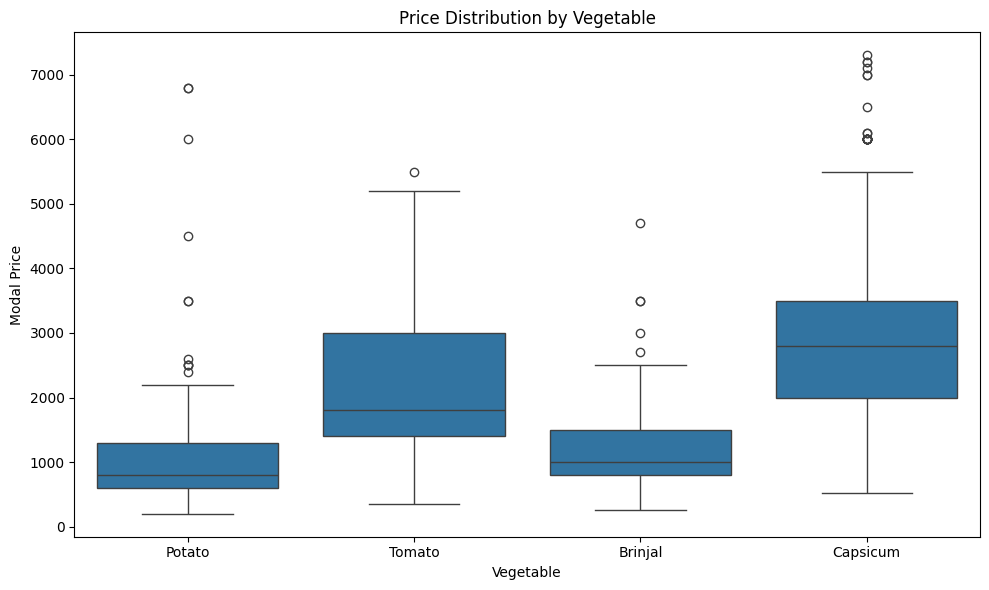

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df, x="Vegetable", y="Modal Price")
plt.title("Price Distribution by Vegetable")
plt.ylabel("Modal Price")
plt.xlabel("Vegetable")
plt.tight_layout()
plt.show()


In [8]:
combined_df["Price Date"] = combined_df["Price Date"].bfill()
combined_df.head()

,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Date,Vegetable
0,1,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,100,300,200,2025-05-05,Potato
1,2,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,2025-05-06,Potato
2,3,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,150,250,200,2025-05-06,Potato
3,4,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,250,2025-05-06,Potato
4,5,Hoshiarpur,Hoshiarpur,Potato,Other,FAQ,200,300,300,2025-05-06,Potato


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_df, x="Price Date", y="Modal Price", hue="Vegetable", marker="o")
plt.title("Modal Price Trends for Vegetables Over Time")
plt.ylabel("Modal Price (Rs./Quintal)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NameError: name 'combined_df' is not defined

<Figure size 1200x600 with 0 Axes>

In [13]:
combined_df.to_excel("cleaned_combined_vegetable_data.xlsx", index=False)


NameError: name 'combined_df' is not defined